# Superstore EDA Project

## Project Overview

This project analyze the Superstore dataset to explore sales performance and profitability across different business dimensions. The analysis focuses on sales and profit distribution, category and sub-category performance, regional differences, time trends, and the impact of discount on profit. The project was completed using Python, pandas, seaborn, and matplotlib in jupyter notebooks. The goal is to identify key patterns, business risks, and useful insights from the dataset.

## Data Loading

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding='latin1')

## Basic Information

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Missing Values

In [7]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Catagorical Analysis

In [8]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

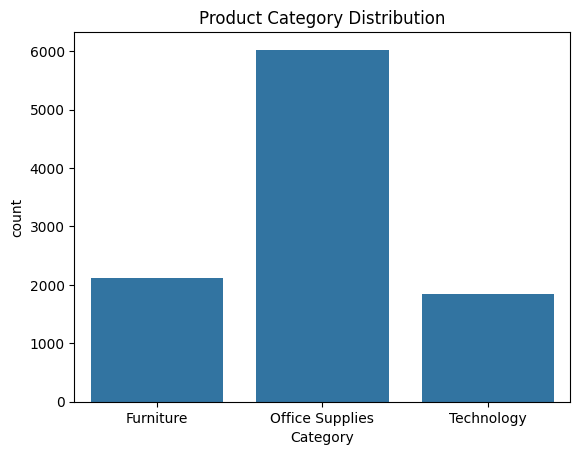

In [9]:
sns.countplot(x="Category", data=df)
plt.title("Product Category Distribution")
plt.show()

## Sub-Category Analysis

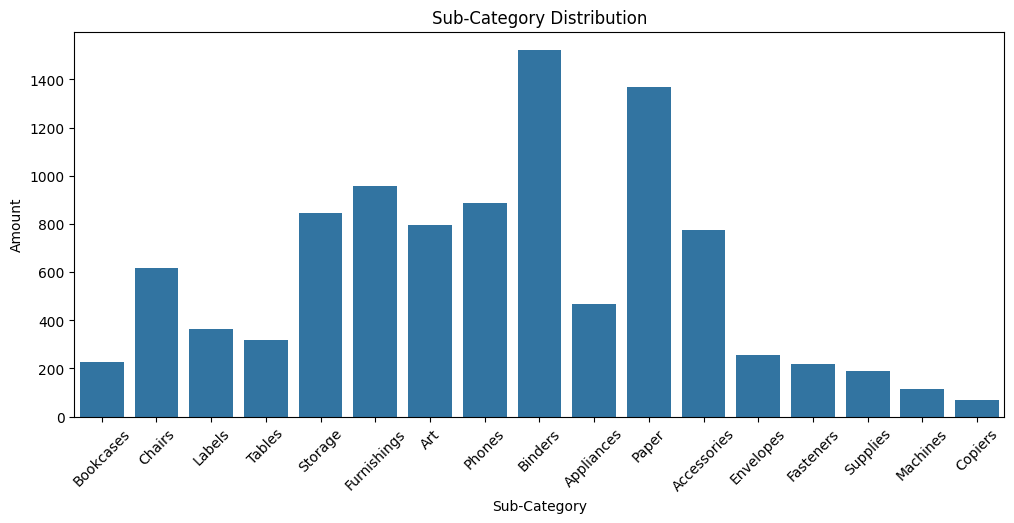

In [6]:
plt.figure(figsize=(12,5))
sns.countplot(x="Sub-Category", data=df)
plt.title("Sub-Category Distribution")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

## Sales Analysis

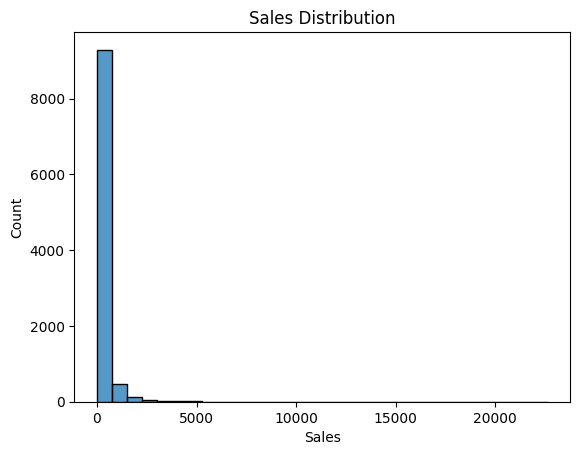

In [7]:
sns.histplot(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.show()

## Profit Analysis

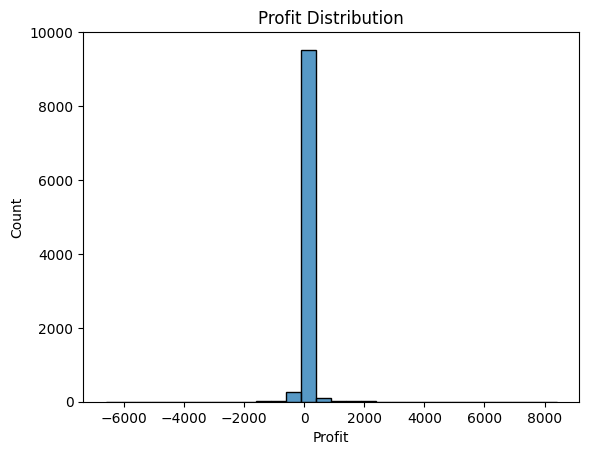

In [8]:
sns.histplot(x="Profit",data=df, bins=30)
plt.title("Profit Distribution")
plt.show()

### Loss Profit

In [9]:
loss_df = df[df["Profit"]<0]
loss_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2017-156909,7/16/2017,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522


In [10]:
loss_df.shape

(1871, 21)

### Sales & Profit

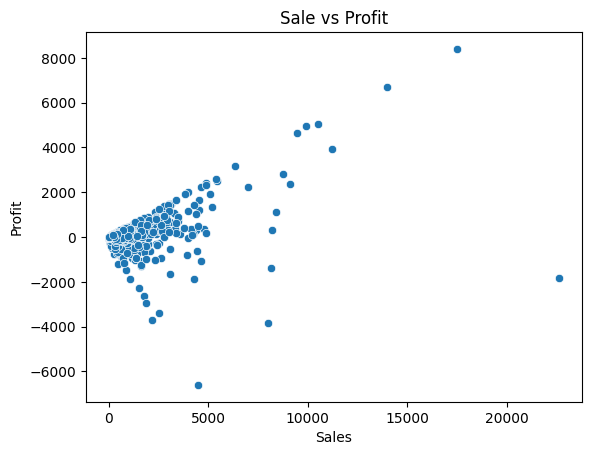

In [11]:
sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sale vs Profit")
plt.show()

## Regional Analysis

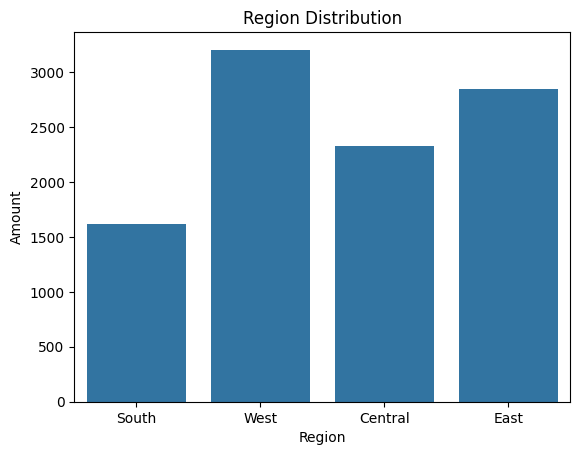

In [12]:
sns.countplot(x="Region", data=df)
plt.title("Region Distribution")
plt.ylabel("Amount")
plt.show()

### Region & Sales

In [13]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

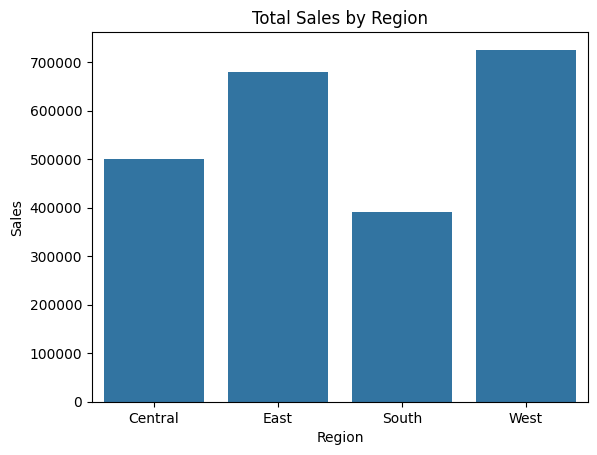

In [14]:
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Total Sales by Region")
plt.show()

### Region & Profit

In [15]:
region_profit = df.groupby("Region")["Profit"].sum()
region_profit

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

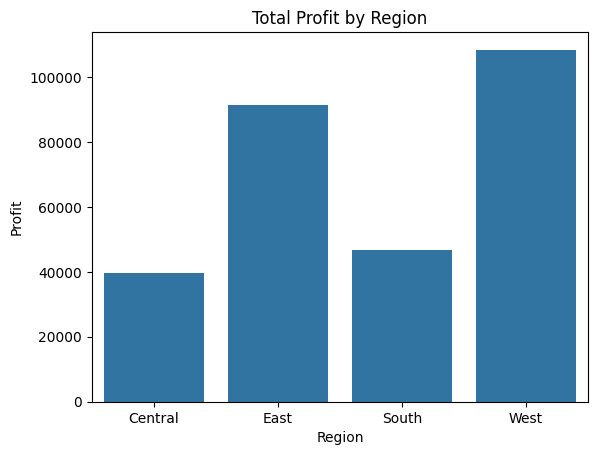

In [16]:
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.xlabel("Region")
plt.ylabel("Profit")
plt.title("Total Profit by Region")
plt.show()

## Time Analysis

### Reset Time Format

In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Date"].head(10)
df["Order Month"] = df["Order Date"].dt.to_period("M")

### Time & Sales

In [18]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()
monthly_sales.head(10)

Order Month
2014-01    14236.8950
2014-02     4519.8920
2014-03    55691.0090
2014-04    28295.3450
2014-05    23648.2870
2014-06    34595.1276
2014-07    33946.3930
2014-08    27909.4685
2014-09    81777.3508
2014-10    31453.3930
Freq: M, Name: Sales, dtype: float64

In [19]:
monthly_sales.index = monthly_sales.index.astype(str)
df[["Order Date", "Order Month"]].head()

,Order Date,Order Month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


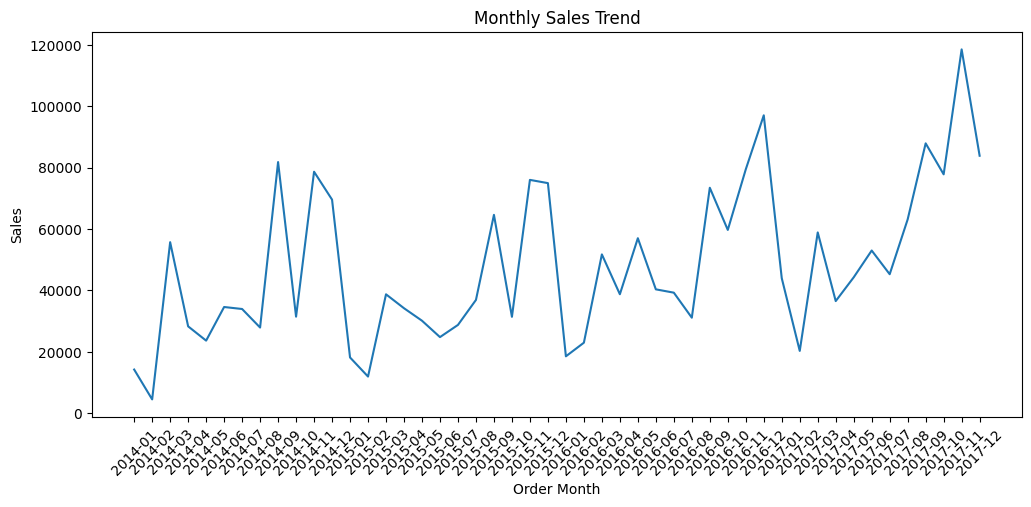

In [20]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Order Month")
plt.ylabel("Sales")
plt.show()

### Time & Profit

In [21]:
monthly_profit = df.groupby("Order Month")["Profit"].sum()
monthly_profit.index = monthly_profit.index.astype(str)
monthly_profit.head(10)

Order Month
2014-01    2450.1907
2014-02     862.3084
2014-03     498.7299
2014-04    3488.8352
2014-05    2738.7096
2014-06    4976.5244
2014-07    -841.4826
2014-08    5318.1050
2014-09    8328.0994
2014-10    3448.2573
Name: Profit, dtype: float64

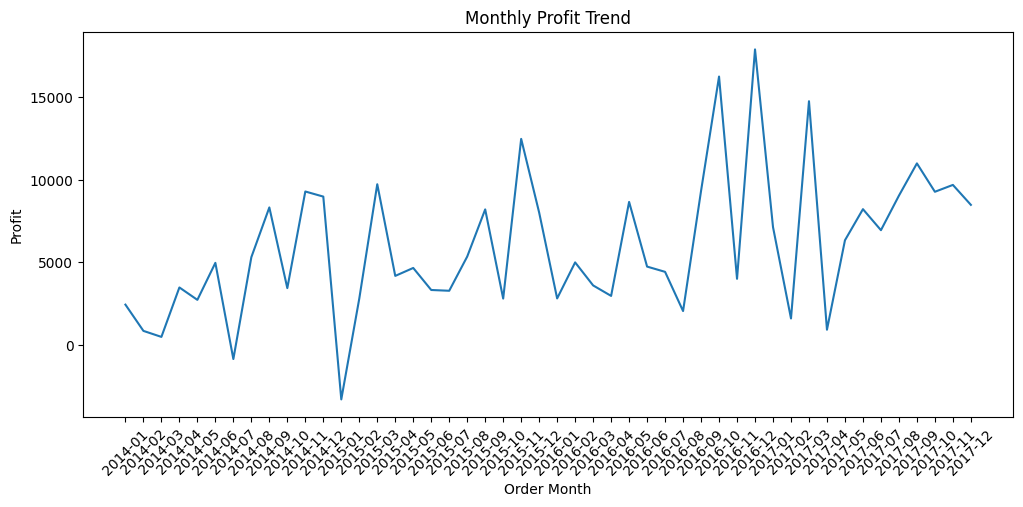

In [22]:
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_profit.index, y=monthly_profit.values)
plt.xticks(rotation=45)
plt.title("Monthly Profit Trend")
plt.xlabel("Order Month")
plt.ylabel("Profit")
plt.show()

## Discount Analysis

In [23]:
df["Discount"].describe

<bound method NDFrame.describe of 0       0.00
1       0.00
2       0.00
3       0.45
4       0.20
        ... 
9989    0.20
9990    0.00
9991    0.20
9992    0.00
9993    0.00
Name: Discount, Length: 9994, dtype: float64>

In [24]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

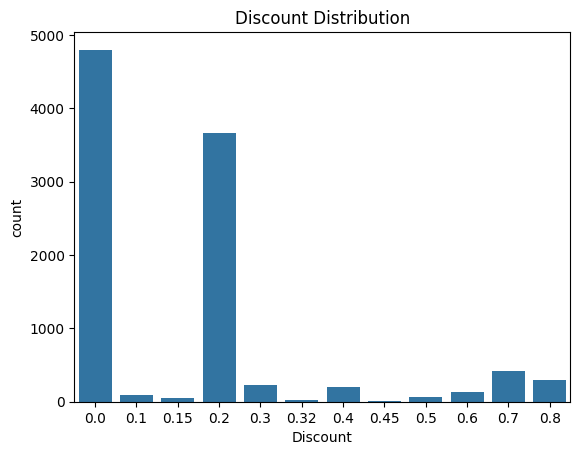

In [25]:
sns.countplot(x="Discount", data=df)
plt.title("Discount Distribution")
plt.show()

### Discount & Profit

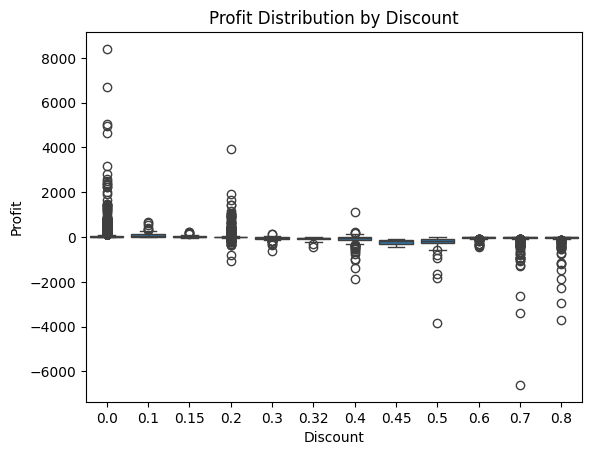

In [26]:
sns.boxplot(x="Discount",y="Profit",data=df)
plt.title("Profit Distribution by Discount")
plt.show()

In [27]:
avg_profit_discount = df.groupby("Discount")["Profit"].mean()
avg_profit_discount

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

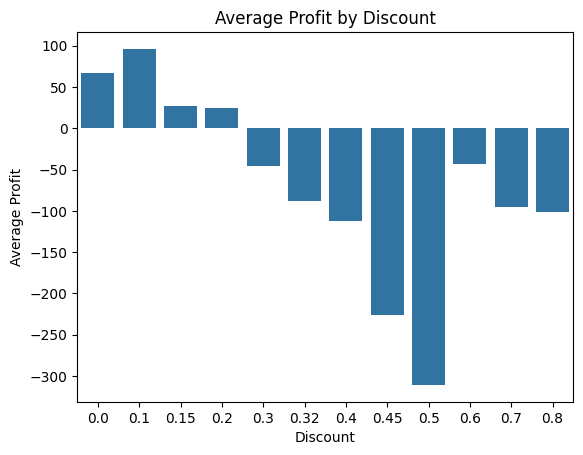

In [28]:
sns.barplot(x=avg_profit_discount.index, y=avg_profit_discount.values)
plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

### High Discount & Profit

In [29]:
high_discount_df = df[df["Discount"]>0.4]
high_discount_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
14,15,US-2015-118983,2015-11-22,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580,2015-11
15,16,US-2015-118983,2015-11-22,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160,2015-11
27,28,US-2015-150630,2015-09-17,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522,2015-09
28,29,US-2015-150630,2015-09-17,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,East,OFF-BI-10000474,Office Supplies,Binders,Avery Recycled Flexi-View Covers for Binding S...,9.6180,2,0.70,-7.0532,2015-09


In [30]:
high_discount_df["Profit"].describe()

count     933.000000
mean     -106.708028
std       381.532681
min     -6599.978000
25%       -52.454400
50%       -13.580000
75%        -4.916400
max        -0.596400
Name: Profit, dtype: float64

In [40]:
(high_discount_df["Profit"]<0).mean()

1.0

## Cross-Dimensional Analysis

### Category & Sales & Profit

In [32]:
category_summary = df.groupby("Category")[["Sales","Profit"]].sum()
category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


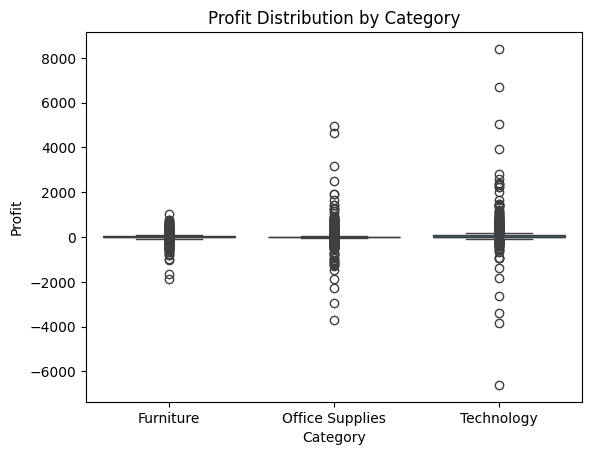

In [33]:
sns.boxplot(x="Category",y="Profit",data=df)
plt.title("Profit Distribution by Category")
plt.show()

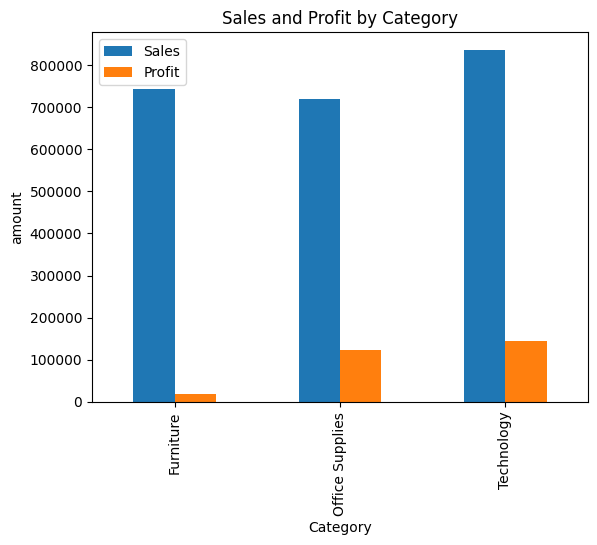

In [34]:
category_summary.plot(kind="bar")
plt.ylabel("amount")
plt.title("Sales and Profit by Category")
plt.show()

### Region & Category & Profit

In [35]:
region_category_profit = df.groupby(["Region","Category"])["Profit"].sum().sort_values().reset_index()
region_category_profit

,Region,Category,Profit
0,Central,Furniture,-2871.0494
1,East,Furniture,3046.1658
2,South,Furniture,6771.2061
3,Central,Office Supplies,8879.9799
4,West,Furniture,11504.9503
5,South,Office Supplies,19986.3928
6,South,Technology,19991.8314
7,Central,Technology,33697.4320
8,East,Office Supplies,41014.5791
9,West,Technology,44303.6496


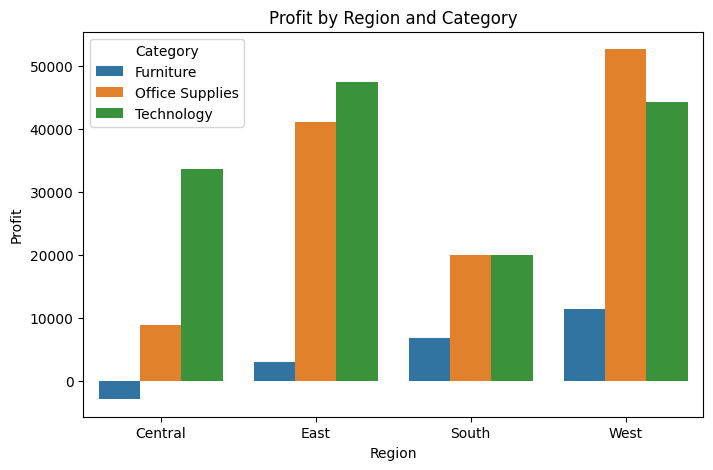

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_category_profit, x="Region", y="Profit", hue="Category")
plt.title("Profit by Region and Category")
plt.show()

### Sub-Category & Sales & Profit

In [37]:
subcat_sales_profit = df.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values("Profit", ascending=False)
subcat_sales_profit

,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


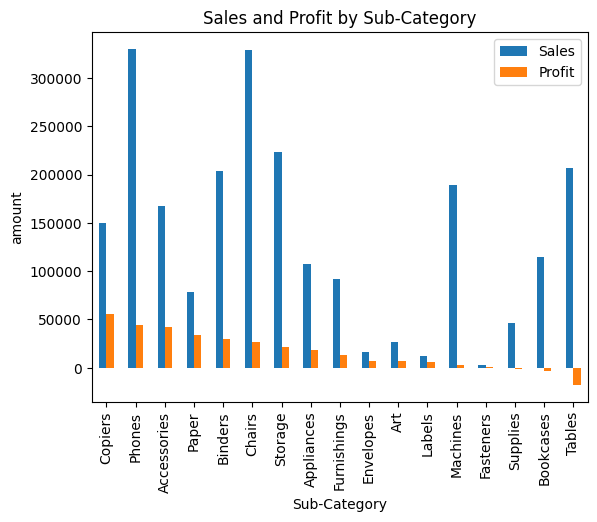

In [38]:
subcat_sales_profit.plot(kind="bar")
plt.ylabel("amount")
plt.title("Sales and Profit by Sub-Category")
plt.show()

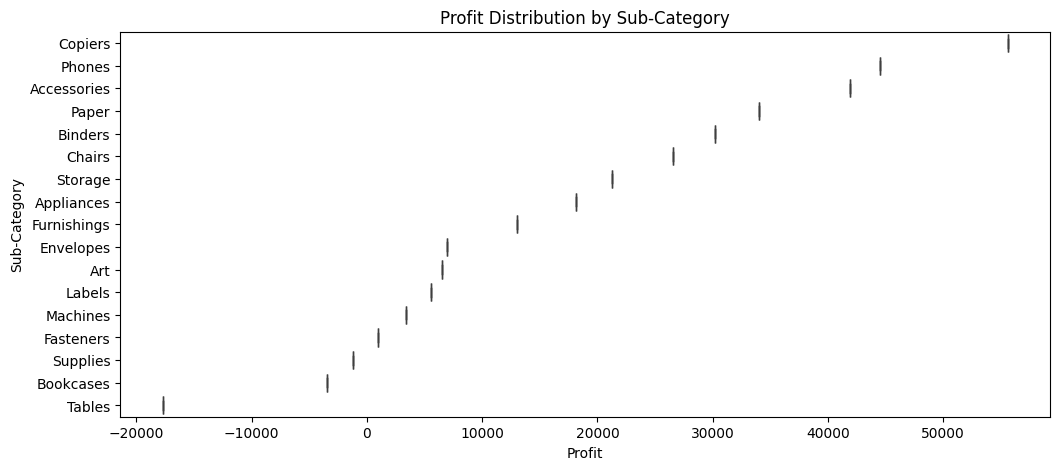

In [39]:
plt.figure(figsize=(12,5))
sns.boxplot(x=subcat_sales_profit["Profit"], y=subcat_sales_profit.index)
plt.title("Profit Distribution by Sub-Category")
plt.ylabel("Sub-Category")
plt.show()

## Key Findings

- The dataset contains 9,994 rows and 21 columns, with no missing values.
- Sales are highly right-skewed, indicating that most orders have relatively low sales values.
- Profit is concentrated around zero, with both positive and negative outcomes.
- The West region has the highest number of orders, the highest total sales, and the highest total profit.
- Office Supplies has by far the highest number of orders among the three categories.
- The Binders sub-category has the highest order count among all sub-categories.
- Sales are generally higher from August to November each year, and the overall sales trend increases over time.
- Profit fluctuates significantly over time and is less stable than sales.
- Discounts are concentrated at 0.0 and 0.2, with about 4,798 orders receiving no discount and 3,657 orders receiving a 0.2 discount.
- Higher discount levels are associated with lower profit.
- Office Supplies in the West region generates the highest profit.
- Furniture in the Central region generates the lowest profit.
- The Copiers sub-category generates the highest profit among all sub-categories.
- The Tables sub-category generates the lowest profit among all sub-categories.

## Project Summary

This project analyzes the Superstore dataset to explore sales performance and profitability across different business dimensions. The dataset contains 9,994 rows and 21 columns, with no missing values, making it suitable for exploratory data analysis. The analysis shows that sales are highly right-skewed, while profit is concentrated around zero and fluctuates considerably over time. The West region performs best in terms of orders, sales, and profit. Sales are generally stronger from August to November and show an overall upward trend over time. Discount is an important factor affecting profitability, and higher discount levels are associated with lower profit. At a more detailed level, profitability varies significantly across categories, regions, and sub-categories.